1. Generating 25-Feature Dataset (with Severe Edge Cases)...
2. Training XGBoost + LightGBM Ensemble...
   -> Accuracy: 99.5%
✅ Edge Cases successfully integrated into the model's memory!

3. Testing on Unseen Custom Patients...
   [Healthy Farmer] -> 🟢 GREEN (99.8%)
   [Obese Smoker] -> 🟡 YELLOW (99.9%)
   [Pregnant BP Spike] -> 🟡 YELLOW (57.9%)

4. Generating SHAP Explanation for the Pregnant BP Spike...


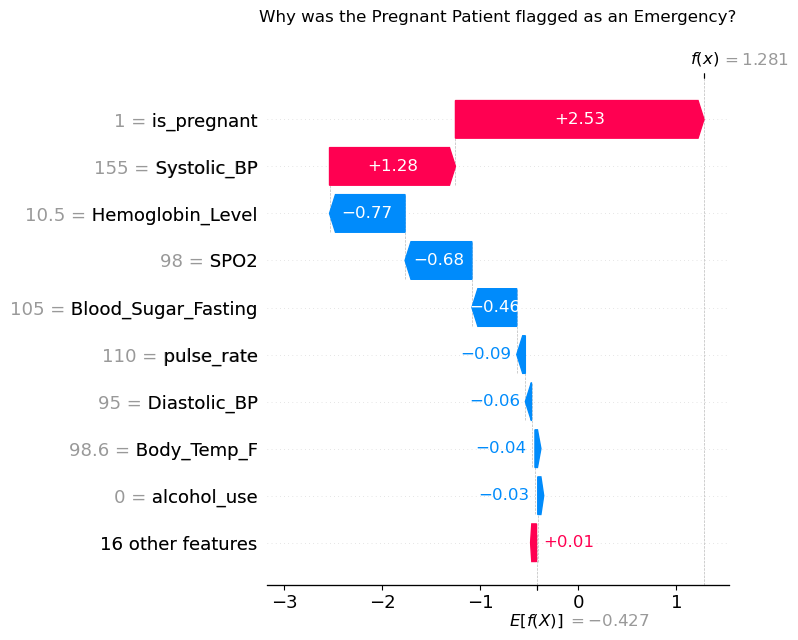

In [3]:
import os
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = r"C:\Users\manom\OneDrive - Manipal University Jaipur\Desktop\manomay\study\python\project_SIH"
FILE_PATH = os.path.join(BASE_DIR, "ultimate_triage_dataset.csv")
MODEL_PATH = os.path.join(BASE_DIR, "ultimate_ensemble_model.pkl")

# =====================================================================
# 1. GENERATE 25-FEATURE SYNTHETIC DATASET (WITH EDGE CASES)
# =====================================================================
np.random.seed(42)
NUM_PATIENTS = 2000
print("1. Generating 25-Feature Dataset (with Severe Edge Cases)...")

records = []
for p_id in range(1, NUM_PATIENTS + 1):
    Age = int(np.random.randint(18, 80))
    is_pregnant = int(np.random.choice([0, 1], p=[0.9, 0.1])) if 18 <= Age <= 40 else 0
    height_cm = round(np.random.normal(160.0, 8.0), 1)
    weight_kg = round(np.random.normal(65.0, 12.0), 1)
    bmi = round(weight_kg / ((height_cm / 100) ** 2), 1)
    smoking_status = int(np.random.choice([0, 1, 2], p=[0.70, 0.10, 0.20]))
    alcohol_use = int(np.random.choice([0, 1], p=[0.75, 0.25]))
    physical_activity = int(np.random.choice([0, 1, 2], p=[0.40, 0.40, 0.20]))
    known_diabetic = int(np.random.choice([0, 1], p=[0.85, 0.15]))
    known_hypertensive = int(np.random.choice([0, 1], p=[0.75, 0.25]))
    on_medication = 1 if (known_diabetic or known_hypertensive) and np.random.rand() > 0.4 else 0
    family_history_diabetes = int(np.random.choice([0, 1], p=[0.4, 0.6])) if known_diabetic else int(np.random.choice([0, 1], p=[0.85, 0.15]))
    family_history_hypertension = int(np.random.choice([0, 1], p=[0.3, 0.7])) if known_hypertensive else int(np.random.choice([0, 1], p=[0.8, 0.2]))
    family_history_heart_disease = int(np.random.choice([0, 1], p=[0.85, 0.15]))
    acute_fever_symptoms = int(np.random.choice([0, 1], p=[0.90, 0.10]))
    Body_Temp_F = round(np.random.uniform(100.5, 104.0), 1) if acute_fever_symptoms else round(np.random.uniform(97.5, 99.0), 1)
    pulse_rate = int(np.random.normal(105, 10)) if acute_fever_symptoms else int(np.random.normal(76, 8))
    Systolic_BP = round(np.random.normal(140, 15), 1) if known_hypertensive else round(np.random.normal(115, 10), 1)
    Diastolic_BP = round(Systolic_BP - np.random.uniform(30, 50), 1)
    Blood_Sugar_Fasting = round(np.random.normal(160, 40), 1) if known_diabetic else round(np.random.normal(90, 10), 1)
    SPO2 = round(np.random.uniform(95, 100), 1)
    if acute_fever_symptoms and np.random.rand() > 0.8: SPO2 = round(np.random.uniform(85, 92), 1)
    Hemoglobin_Level = round(np.random.normal(11.0, 1.5), 1) if is_pregnant else round(np.random.normal(13.5, 1.5), 1)
    Delta_SystolicBP = round(np.random.normal(0, 5), 1)
    Delta_Hemoglobin = round(np.random.normal(0, 0.5), 1)
    Delta_BloodSugar = round(np.random.normal(0, 10), 1)

    # 🚨 EXPLICIT EDGE CASE INJECTION 🚨
    # We force the first 150 patients to be severe emergencies so the model learns the rules
    if p_id <= 50:
        is_pregnant = 1
        Hemoglobin_Level = round(np.random.uniform(5.0, 7.3), 1) # Forced Severe Anemia
    elif p_id <= 100:
        acute_fever_symptoms = 1
        SPO2 = round(np.random.uniform(80, 91), 1) # Forced Respiratory Failure
    elif p_id <= 150:
        known_diabetic = 1
        Blood_Sugar_Fasting = round(np.random.uniform(320, 450), 1) # Forced Diabetic Crisis

    # TARGET LOGIC
    Triage_Action = 0 
    if (SPO2 < 92 or Systolic_BP > 170 or Blood_Sugar_Fasting > 300 or (is_pregnant and Systolic_BP > 150) or Hemoglobin_Level < 7.5):
        Triage_Action = 2
    elif (bmi > 32 or Systolic_BP > 140 or Blood_Sugar_Fasting > 150 or Body_Temp_F > 101.5 or (smoking_status == 2 and family_history_heart_disease == 1)):
        Triage_Action = 1

    records.append({
        'Age': Age, 'is_pregnant': is_pregnant, 'height_cm': height_cm, 'weight_kg': weight_kg, 'bmi': bmi,
        'smoking_status': smoking_status, 'alcohol_use': alcohol_use, 'physical_activity': physical_activity,
        'known_diabetic': known_diabetic, 'known_hypertensive': known_hypertensive, 'on_medication': on_medication,
        'family_history_diabetes': family_history_diabetes, 'family_history_hypertension': family_history_hypertension, 
        'family_history_heart_disease': family_history_heart_disease, 'acute_fever_symptoms': acute_fever_symptoms, 
        'Body_Temp_F': Body_Temp_F, 'pulse_rate': pulse_rate, 'Systolic_BP': Systolic_BP, 'Diastolic_BP': Diastolic_BP, 
        'Blood_Sugar_Fasting': Blood_Sugar_Fasting, 'SPO2': SPO2, 'Hemoglobin_Level': Hemoglobin_Level,
        'Delta_SystolicBP': Delta_SystolicBP, 'Delta_Hemoglobin': Delta_Hemoglobin, 'Delta_BloodSugar': Delta_BloodSugar,
        'Triage_Action': Triage_Action
    })

df_unified = pd.DataFrame(records)
df_unified.to_csv(FILE_PATH, index=False)

# =====================================================================
# 2. TRAIN THE ENSEMBLE MODEL
# =====================================================================
print("2. Training XGBoost + LightGBM Ensemble...")
X = df_unified.drop(columns=['Triage_Action'])
y = df_unified['Triage_Action']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

xgb_model = xgb.XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.05, eval_metric='mlogloss', random_state=42)
lgb_model = lgb.LGBMClassifier(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42, verbose=-1)

ensemble_model = VotingClassifier(estimators=[('xgb', xgb_model), ('lgb', lgb_model)], voting='soft')
ensemble_model.fit(X_train, y_train)

joblib.dump(ensemble_model, MODEL_PATH)
print(f"   -> Accuracy: {ensemble_model.score(X_test, y_test) * 100:.1f}%")
print("✅ Edge Cases successfully integrated into the model's memory!")

# =====================================================================
# 3. TEST ON UNSEEN CUSTOM PATIENTS (25 Features)
# =====================================================================
print("\n3. Testing on Unseen Custom Patients...")

patient_green = {
    'Age': 45, 'is_pregnant': 0, 'height_cm': 170.0, 'weight_kg': 68.0, 'bmi': 23.5,
    'smoking_status': 0, 'alcohol_use': 0, 'physical_activity': 2, 'known_diabetic': 0, 'known_hypertensive': 0, 'on_medication': 0,
    'family_history_diabetes': 0, 'family_history_hypertension': 0, 'family_history_heart_disease': 0,
    'acute_fever_symptoms': 0, 'Body_Temp_F': 98.4, 'pulse_rate': 72, 'Systolic_BP': 118.0, 'Diastolic_BP': 78.0, 
    'Blood_Sugar_Fasting': 92.0, 'SPO2': 99.0, 'Hemoglobin_Level': 13.2, 'Delta_SystolicBP': 1.0, 'Delta_Hemoglobin': 0.1, 'Delta_BloodSugar': -3.0
}

patient_yellow = {
    'Age': 55, 'is_pregnant': 0, 'height_cm': 165.0, 'weight_kg': 95.0, 'bmi': 34.9, # High BMI (Yellow flag)
    'smoking_status': 2, 'alcohol_use': 1, 'physical_activity': 0, 'known_diabetic': 0, 'known_hypertensive': 1, 'on_medication': 1,
    'family_history_diabetes': 0, 'family_history_hypertension': 1, 'family_history_heart_disease': 1,
    'acute_fever_symptoms': 0, 'Body_Temp_F': 98.6, 'pulse_rate': 85, 'Systolic_BP': 138.0, 'Diastolic_BP': 88.0, 
    'Blood_Sugar_Fasting': 110.0, 'SPO2': 97.0, 'Hemoglobin_Level': 12.5, 'Delta_SystolicBP': 4.0, 'Delta_Hemoglobin': 0.0, 'Delta_BloodSugar': 5.0
}

patient_red = {
    'Age': 26, 'is_pregnant': 1, 'height_cm': 155.0, 'weight_kg': 60.0, 'bmi': 25.0,
    'smoking_status': 0, 'alcohol_use': 0, 'physical_activity': 1, 'known_diabetic': 0, 'known_hypertensive': 0, 'on_medication': 0,
    'family_history_diabetes': 0, 'family_history_hypertension': 0, 'family_history_heart_disease': 0,
    'acute_fever_symptoms': 0, 'Body_Temp_F': 98.6, 'pulse_rate': 110, 'Systolic_BP': 155.0, 'Diastolic_BP': 95.0, # Pregnant BP Spike (Red flag)
    'Blood_Sugar_Fasting': 105.0, 'SPO2': 98.0, 'Hemoglobin_Level': 10.5, 'Delta_SystolicBP': 22.0, 'Delta_Hemoglobin': -0.2, 'Delta_BloodSugar': 2.0
}

df_custom = pd.DataFrame([patient_green, patient_yellow, patient_red], 
                         index=["Healthy Farmer", "Obese Smoker", "Pregnant BP Spike"])

# The Magic Fix: Align columns
internal_xgb = ensemble_model.named_estimators_['xgb']
df_custom = df_custom[internal_xgb.feature_names_in_]

preds = ensemble_model.predict(df_custom)
probs = ensemble_model.predict_proba(df_custom)
labels = {0: "🟢 GREEN", 1: "🟡 YELLOW", 2: "🔴 RED (Emergency)"}

for i, name in enumerate(df_custom.index):
    print(f"   [{name}] -> {labels[preds[i]]} ({probs[i][preds[i]]*100:.1f}%)")

# =====================================================================
# 4. SHAP EXPLAINER
# =====================================================================
print("\n4. Generating SHAP Explanation for the Pregnant BP Spike...")
explainer = shap.TreeExplainer(internal_xgb)
shap_obj = explainer(df_custom)

plt.figure(figsize=(8, 6))
# Index 2 is the 'Pregnant BP Spike' patient, Class 2 is 'Red'
shap.plots.waterfall(shap_obj[2, :, 2], max_display=10, show=False)
plt.title("Why was the Pregnant Patient flagged as an Emergency?", pad=20)
plt.tight_layout()
plt.show()

In [5]:
import os
import pandas as pd
import joblib

# -------------------------------------------------------------
# 1. LOAD THE MODEL
# -------------------------------------------------------------
BASE_DIR = r"C:\Users\manom\OneDrive - Manipal University Jaipur\Desktop\manomay\study\python\project_SIH"
MODEL_PATH = os.path.join(BASE_DIR, "ultimate_ensemble_model.pkl")

print("Loading the Edge-Case Trained 25-Feature Brain...")
ensemble_model = joblib.load(MODEL_PATH)
internal_xgb = ensemble_model.named_estimators_['xgb']

# -------------------------------------------------------------
# 2. DEFINE 5 NEW REALISTIC RURAL PATIENTS
# -------------------------------------------------------------
patients = [
    {
        # Patient 1: Kavita (28, Pregnant, Preeclampsia BP Spike) -> Should be RED
        'Age': 28, 'is_pregnant': 1, 'height_cm': 155.0, 'weight_kg': 65.0, 'bmi': 27.1,
        'smoking_status': 0, 'alcohol_use': 0, 'physical_activity': 1, 
        'known_diabetic': 0, 'known_hypertensive': 0, 'on_medication': 0,
        'family_history_diabetes': 0, 'family_history_hypertension': 1, 'family_history_heart_disease': 0,
        'acute_fever_symptoms': 0, 'Body_Temp_F': 98.6, 'pulse_rate': 95, 
        'Systolic_BP': 165.0, 'Diastolic_BP': 105.0, 'Blood_Sugar_Fasting': 95.0, 
        'SPO2': 99.0, 'Hemoglobin_Level': 11.0, 
        'Delta_SystolicBP': 45.0, 'Delta_Hemoglobin': 0.2, 'Delta_BloodSugar': 2.0
    },
    {
        # Patient 2: Harish (55, Stopped Meds, Massive Diabetic Crisis) -> Should be RED
        'Age': 55, 'is_pregnant': 0, 'height_cm': 165.0, 'weight_kg': 60.0, 'bmi': 22.0,
        'smoking_status': 1, 'alcohol_use': 1, 'physical_activity': 1, 
        'known_diabetic': 1, 'known_hypertensive': 0, 'on_medication': 0, # Stopped meds
        'family_history_diabetes': 1, 'family_history_hypertension': 0, 'family_history_heart_disease': 0,
        'acute_fever_symptoms': 0, 'Body_Temp_F': 98.4, 'pulse_rate': 102, 
        'Systolic_BP': 130.0, 'Diastolic_BP': 82.0, 'Blood_Sugar_Fasting': 410.0, # DANGER: Extreme Sugar
        'SPO2': 97.0, 'Hemoglobin_Level': 13.0, 
        'Delta_SystolicBP': 2.0, 'Delta_Hemoglobin': -0.1, 'Delta_BloodSugar': 150.0
    },
    {
        # Patient 3: Mohan (72, Heavy Smoker, Dropping Oxygen) -> Should be RED
        'Age': 72, 'is_pregnant': 0, 'height_cm': 160.0, 'weight_kg': 50.0, 'bmi': 19.5,
        'smoking_status': 2, 'alcohol_use': 0, 'physical_activity': 0, 
        'known_diabetic': 0, 'known_hypertensive': 1, 'on_medication': 1,
        'family_history_diabetes': 0, 'family_history_hypertension': 1, 'family_history_heart_disease': 1,
        'acute_fever_symptoms': 1, 'Body_Temp_F': 102.0, 'pulse_rate': 112, 
        'Systolic_BP': 135.0, 'Diastolic_BP': 80.0, 'Blood_Sugar_Fasting': 105.0, 
        'SPO2': 86.0, 'Hemoglobin_Level': 12.0, # DANGER: Low Oxygen
        'Delta_SystolicBP': -10.0, 'Delta_Hemoglobin': -0.5, 'Delta_BloodSugar': -5.0
    },
    {
        # Patient 4: Lakshmi (50, Undiagnosed Hypertension, High BMI) -> Should be YELLOW
        'Age': 50, 'is_pregnant': 0, 'height_cm': 150.0, 'weight_kg': 75.0, 'bmi': 33.3,
        'smoking_status': 0, 'alcohol_use': 0, 'physical_activity': 0, 
        'known_diabetic': 0, 'known_hypertensive': 0, 'on_medication': 0,
        'family_history_diabetes': 1, 'family_history_hypertension': 1, 'family_history_heart_disease': 0,
        'acute_fever_symptoms': 0, 'Body_Temp_F': 98.6, 'pulse_rate': 80, 
        'Systolic_BP': 142.0, 'Diastolic_BP': 88.0, 'Blood_Sugar_Fasting': 110.0, # Borderline BP & High BMI
        'SPO2': 98.0, 'Hemoglobin_Level': 11.5, 
        'Delta_SystolicBP': 10.0, 'Delta_Hemoglobin': 0.0, 'Delta_BloodSugar': 5.0
    },
    {
        # Patient 5: Rahul (22, Student, Mild Fever) -> Should be GREEN
        'Age': 22, 'is_pregnant': 0, 'height_cm': 175.0, 'weight_kg': 68.0, 'bmi': 22.2,
        'smoking_status': 0, 'alcohol_use': 0, 'physical_activity': 2, 
        'known_diabetic': 0, 'known_hypertensive': 0, 'on_medication': 0,
        'family_history_diabetes': 0, 'family_history_hypertension': 0, 'family_history_heart_disease': 0,
        'acute_fever_symptoms': 1, 'Body_Temp_F': 99.8, 'pulse_rate': 88, # Mild viral temp
        'Systolic_BP': 120.0, 'Diastolic_BP': 75.0, 'Blood_Sugar_Fasting': 90.0, 
        'SPO2': 98.0, 'Hemoglobin_Level': 14.5, 
        'Delta_SystolicBP': 0.0, 'Delta_Hemoglobin': 0.0, 'Delta_BloodSugar': 0.0
    }
]

df_test = pd.DataFrame(patients, index=[
    "1. Kavita (Pregnant, High BP)", 
    "2. Harish (Massive Sugar Spike)", 
    "3. Mohan (Elderly, Dropping SPO2)", 
    "4. Lakshmi (High BMI, Borderline BP)", 
    "5. Rahul (Young, Mild Viral)"
])

# ✅ THE MAGIC FIX: Align the columns perfectly!
df_test = df_test[internal_xgb.feature_names_in_]

# -------------------------------------------------------------
# 3. RUN PREDICTIONS
# -------------------------------------------------------------
predictions = ensemble_model.predict(df_test)
probabilities = ensemble_model.predict_proba(df_test)

labels = {0: "🟢 GREEN (Routine PHC Care)", 1: "🟡 YELLOW (CHC Monitor/Meds)", 2: "🔴 RED (Urgent District Referral)"}

print("\n" + "="*70)
print("SIH RURAL CLINIC: 25-FEATURE LIVE TRIAGE")
print("="*70)

for i, name in enumerate(df_test.index):
    pred_class = predictions[i]
    confidence = probabilities[i][pred_class] * 100
    
    print(f"\nPatient: {name}")
    print(f"  -> Triage Decision: {labels[pred_class]}")
    print(f"  -> Model Confidence: {confidence:.1f}%")

Loading the Edge-Case Trained 25-Feature Brain...

SIH RURAL CLINIC: 25-FEATURE LIVE TRIAGE

Patient: 1. Kavita (Pregnant, High BP)
  -> Triage Decision: 🔴 RED (Urgent District Referral)
  -> Model Confidence: 71.2%

Patient: 2. Harish (Massive Sugar Spike)
  -> Triage Decision: 🔴 RED (Urgent District Referral)
  -> Model Confidence: 99.6%

Patient: 3. Mohan (Elderly, Dropping SPO2)
  -> Triage Decision: 🔴 RED (Urgent District Referral)
  -> Model Confidence: 85.3%

Patient: 4. Lakshmi (High BMI, Borderline BP)
  -> Triage Decision: 🟡 YELLOW (CHC Monitor/Meds)
  -> Model Confidence: 99.9%

Patient: 5. Rahul (Young, Mild Viral)
  -> Triage Decision: 🟢 GREEN (Routine PHC Care)
  -> Model Confidence: 99.2%
